In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist

In [2]:
from dask.distributed import Client
client = Client(n_workers=2, threads_per_worker=3, memory_limit=15e9)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 6,Total memory: 27.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35709,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37983,Total threads: 3
Dashboard: http://127.0.0.1:39933/status,Memory: 13.97 GiB
Nanny: tcp://127.0.0.1:44843,


In [3]:
!echo dask dashboard :D
!echo https://jupyterhub.dkrz.de/user/$USER/levante-spawner-preset/proxy/8787/status

dask dashboard :D
https://jupyterhub.dkrz.de/user/b383184/levante-spawner-preset/proxy/8787/status


In [4]:
stores = sorted(Path("/work/bk1450/b383184/Amazon/Atlantic/data/tracks").glob("Parcels_run_*_*.zarr"))
stores[:3]

[PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks/Parcels_run_1234_2022-06-01T00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks/Parcels_run_1234_2022-07-01T00:00:00.zarr'),
 PosixPath('/work/bk1450/b383184/Amazon/Atlantic/data/tracks/Parcels_run_1234_2022-08-01T00:00:00.zarr')]

In [5]:
ds_list = [xr.open_zarr(s) for s in stores]
ds = xr.concat(ds_list,dim='trajectory')

ds

<xarray.Dataset> Size: 70GB
Dimensions:     (trajectory: 3800000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 30MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat         (trajectory, obs) float32 14GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 14GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 28GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 14GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [10]:
num_valid_obs_steps = int(ds.lat.notnull().any('trajectory').sum().compute().data[()])
ds = ds.isel(obs=slice(None, num_valid_obs_steps))
ds

<xarray.Dataset> Size: 56GB
Dimensions:      (trajectory: 3800000, obs: 741)
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory   (trajectory) int64 30MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat          (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    lon          (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    time         (trajectory, obs) datetime64[ns] 23GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    z            (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    start_time   (trajectory) datetime64[ns] 30MB 2022-06-01 ... 2025-07-01
    start_year   (trajectory) int64 30MB 2022 2022 2022 2022 ... 2025 2025 2025
    start_month  (trajectory) int64 30MB 6 6 6 6 6 6 6 6 6 ... 7 7 7 7 7 7 7 7 7
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [2]:
ds = ds.assign(start_time=ds.time.isel(obs=0).compute())
ds = ds.assign(start_year=ds.start_time.dt.year)
ds = ds.assign(start_month=ds.start_time.dt.month)
ds

NameError: name 'ds' is not defined

In [1]:
lat_min=ds.lat.min().compute().data[()]
lon_min=ds.lon.min().compute().data[()]

lat_max=ds.lat.max().compute().data[()]
lon_max=ds.lon.max().compute().data[()]

NameError: name 'ds' is not defined

In [13]:
import numpy as np

lat_bins = np.linspace(lat_min,lat_max,30)
lon_bins = np.linspace(lon_min,lon_max,30)

def calc_hist(ds):
    return xhist(
        ds.lon,
        ds.lat,
        bins=[lon_bins, lat_bins],
        dim=["trajectory", ],
        bin_dim_suffix=""
    )

In [14]:
# calc hist for each start year / start month
hist = ds.groupby(["start_year", "start_month"]).apply(calc_hist)

# aggregate obs into 5 day bins (with 4 steps each day), skipping the initial positions
hist = hist.isel(obs=slice(1, None)).coarsen(obs=4 * 5, boundary="trim").sum()

# compute and store to file
hist.drop_encoding().compute().to_netcdf("_hist.nc")

# reload
hist = xr.open_dataset("_hist.nc").compute().histogram_lon_lat
hist

/work/bk1450/b383184/conda/envs/parcels_3.1.2/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 30.36 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.DataArray 'histogram_lon_lat' (obs: 37, lon: 29, lat: 29,
                                       start_year: 4, start_month: 12)> Size: 12MB
array([[[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         ...,

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
...
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         ...,

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]],

         [[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]]]], shape=(37, 29, 29, 4, 12))
Coordinates:
  * start_year   (start_year) int64 32B 2022 2023 2024 2025
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * obs          (obs) float64 296B 10.5 30.5 50.5 70.5 ... 690.5 710.5 730.5
  * lon          (lon) float32 116B -90.52 -87.34 -84.17 ... -7.94 -4.764 -1.588
  * lat          (lat) float32 116B -5.54 -4.011 -2.482 ... 34.22 35.75 37.28

In [16]:
from matplotlib import pyplot as plt
import cartopy

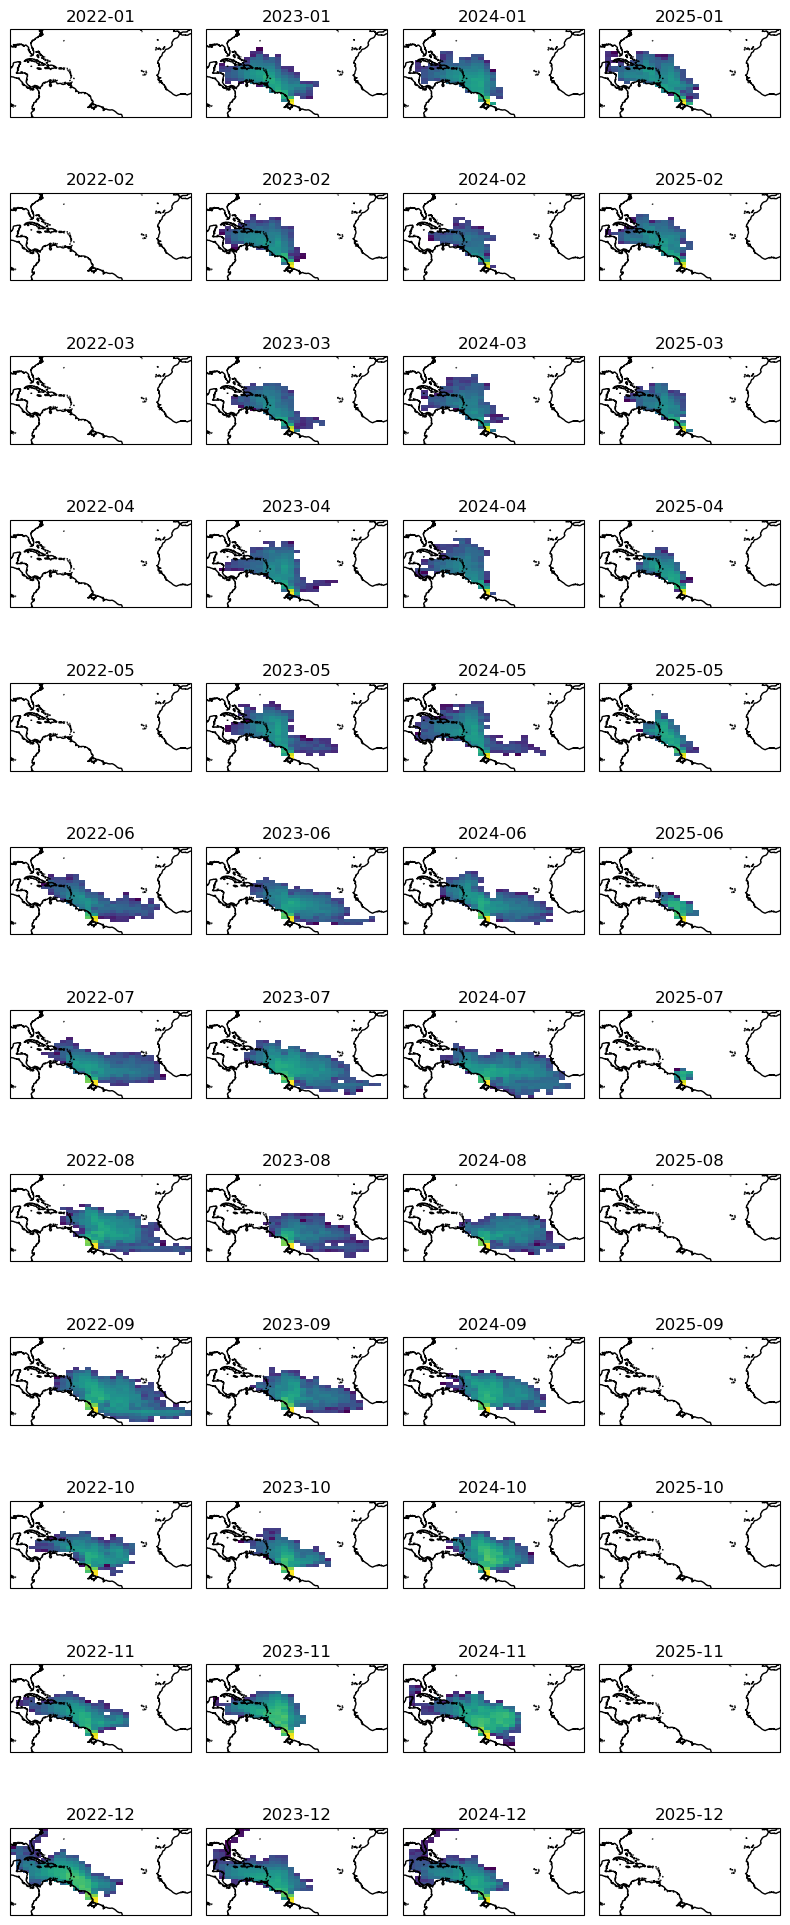

In [12]:
fig, ax = plt.subplots(
    len(np.unique(hist.start_month.data)),
    len(np.unique(hist.start_year.data)),
    figsize=(8, 20),
    subplot_kw={"projection": cartopy.crs.PlateCarree()},
)

np.seterr(divide = 'ignore')  # Don't warn on np.log10 on invalid or 0 data
for nyr, syr in enumerate(sorted(np.unique(hist.start_year.data))):
    for nmon, smon  in enumerate(sorted(np.unique(hist.start_month.data))):
        _ax = ax[nmon, nyr]
        np.log10(hist.sel(start_year=syr, start_month=smon).sum("obs")).plot(
            x="lon", y="lat", 
            transform=cartopy.crs.PlateCarree(), ax=_ax,
            add_colorbar=False
        )
        _ax.set_title(f"{syr:04d}-{smon:02d}")
        _ax.coastlines();
fig.tight_layout();